<p style="font-size: 22px; font-weight: bold; margin: 0;">
  Alpaycan CABBAR 
</p>

<h1 style="text-align: center; margin-top: 0; font-size: 40px; font-weight: bold; margin-top: 0;">
  Multi-Class Dice Classification with a Convolutional Neural Network
</h1>

### Introduction

        This project explores the use of Convolutional Neural Networks (CNNs) for image classification by developing a deep learning model capable of recognizing the face value of dice from grayscale images. The objective was to build, train, and evaluate a CNN that can accurately classify images into six different classes, corresponding to the six possible outcomes of a standard die.

        The dataset consists of 28 × 28 grayscale images represented as flattened pixel values. Throughout the project, I performed dataset exploration and visualization, designed and implemented a custom CNN architecture using PyTorch, and evaluated the model using training, validation, and test datasets. Several techniques were applied to improve performance and generalization, including batch normalization, dropout regularization, adaptive pooling, learning rate scheduling, and early stopping.

        The project demonstrates the complete deep learning workflow, from data exploration and preprocessing to model development, training optimization, performance evaluation, and analysis of model generalization. The final model achieved strong classification performance while maintaining computational efficiency, highlighting the effectiveness of convolutional neural networks for image recognition tasks.

        This project was developed as a personal machine learning portfolio project to strengthen practical experience with deep learning, computer vision, and the PyTorch framework.


### Data loading

In [1]:
import numpy as np
import pandas as pd

data_df = pd.read_csv('data.csv')
data_df


,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,5,110,107,103,100,97,94,90,87,84,...,29,26,22,19,16,13,9,6,3,0
1,5,10,10,10,9,9,8,8,8,7,...,111,100,86,81,78,77,76,75,75,75
2,1,0,0,1,1,2,3,3,4,5,...,61,62,63,63,64,65,65,66,67,67
3,1,10,11,12,13,14,15,15,16,17,...,17,16,17,18,19,20,21,22,23,23
4,6,29,28,27,25,24,23,22,21,20,...,19,18,17,16,15,14,12,11,10,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,4,0,0,0,1,1,2,2,2,3,...,53,53,54,54,55,55,55,56,56,57
380,3,15,15,14,14,13,12,12,11,11,...,56,55,55,54,54,53,52,52,51,51
381,3,20,19,18,18,17,16,15,15,14,...,40,40,39,38,37,36,36,35,34,33
382,2,40,41,42,42,43,44,45,45,46,...,13,13,14,15,16,16,17,18,19,19


## 1. Data exploration, model selection and data pre-processing

In [2]:
import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

### 1.1. Shape of the dataset

In [3]:
n_samples = data_df.shape[0]
n_columns = data_df.shape[1]
n_pixel_features = n_columns - 1
image_size = int(np.sqrt(n_pixel_features))
n_classes = data_df["label"].nunique()
pixel_data = data_df.iloc[:, 1:]
missing_values = pixel_data.isnull().sum().sum()
pixel_dtype = pixel_data.dtypes.iloc[0]


summary_table = pd.DataFrame({
    "Item": [
        "Image size",
        "Pixel features",
        "Pixel data type",
        "Missing values",
        "Number of classes",
        "Number of samples",
        "Number of columns",  
        "Task type",
        "Image format"
    ],
    "Value": [
        f"{image_size} x {image_size}",
        n_pixel_features,
        str(pixel_dtype),
        missing_values,
        n_classes,
        n_samples,
        n_columns,
        "Multi-class classification",
        "Flattened grayscale image"
    ]
})

summary_table

,Item,Value
0,Image size,28 x 28
1,Pixel features,784
2,Pixel data type,int64
3,Missing values,0
4,Number of classes,6
5,Number of samples,384
6,Number of columns,785
7,Task type,Multi-class classification
8,Image format,Flattened grayscale image


        The dataset is stored in tabular form as a dataframe. Each row represents one image sample, and each column represents one variable. The dataset contains a "label" column, which is the target for the classification task, and the remaining columns contain pixel values. There are 784 pixel features for each sample. Since 784 = 28 × 28, each image is stored in flattened form and can be reshaped into a 28 × 28 grayscale image. This means the task is a supervised multi-class image classification problem.

### 1.2. Examination of the image data

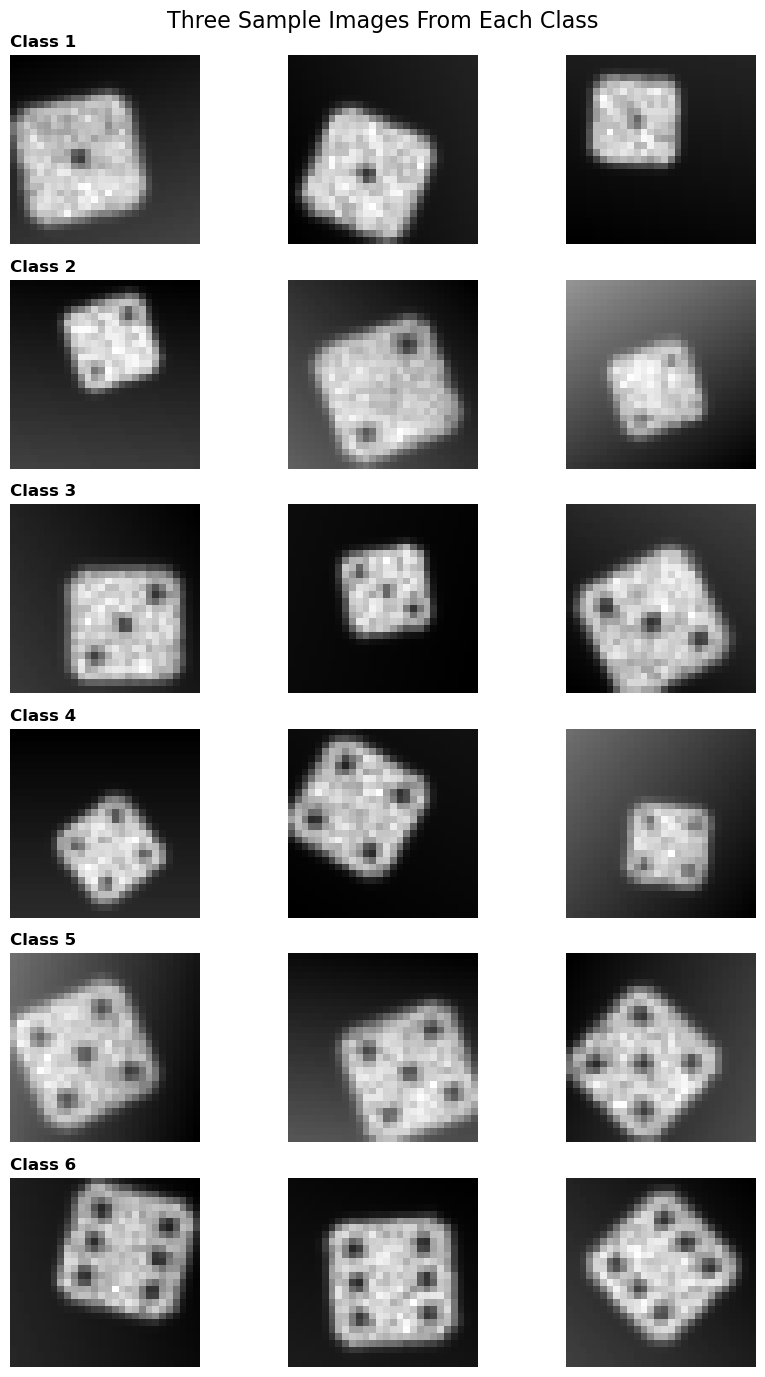

In [4]:
classes = sorted(data_df["label"].unique())
fig, axes = plt.subplots(len(classes), 3, figsize=(9, 14))

for row, c in enumerate(classes):
    class_samples = data_df[data_df["label"] == c].iloc[:3, 1:].to_numpy()

    for col in range(3):
        img = class_samples[col].reshape(28, 28)
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(f"Class {c}", loc="left", fontsize=12, fontweight="bold")

plt.suptitle("Three Sample Images From Each Class", fontsize=16)
plt.tight_layout()
plt.show()

### 1.3. Qualitative examination of the image data

- The pictures are black and white and not very clear, so they look a little blurry and pixelated. But most of the time, you can still see the shape of the die and the dots, and the background is usually dark enough to tell the difference. 

- The pictures are not always the same size, position, or angle. Some show rotation, shifting, and small changes in brightness or background shading. This means that the classifier needs to be able to recognize the dot patterns even when they change a little bit.

- Overall, the classes look like they are separate because each one has a different number of dots and a different arrangement of dots. It's easy to tell the difference between the extreme classes, like 1 and 6, but the middle classes may be a little harder to tell apart.

### 1.4. Determining indexes for the classification task

In [5]:
print("Original labels:", sorted(data_df["label"].unique()))

data_df["class_idx"] = data_df["label"] - 1
print("Class indexes:", sorted(data_df["class_idx"].unique()))

mapping_table = pd.DataFrame({
    "Original label": [1, 2, 3, 4, 5, 6],
    "Class index":    [0, 1, 2, 3, 4, 5]
})

mapping_table

Original labels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Class indexes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


,Original label,Class index
0,1,0
1,2,1
2,3,2
3,4,3
4,5,4
5,6,5


        The original labels for the dataset were the numbers 1 to 6 on the dice. For the classification model, these labels were changed to class indexes from 0 to 5. This is a normal step for multi-class classification in PyTorch because "CrossEntropyLoss" expects target labels to start at 0.

        The mapping used is:

            - 1 → 0  
            - 2 → 1  
            - 3 → 2  
            - 4 → 3  
            - 5 → 4  
            - 6 → 5

### 1.5. Type of model I used in this project

        This task is a supervised multi-class image classification problem. A 28 × 28 grayscale image of a die is the input, and the number of dots on the die face is the output. A convolutional neural network (CNN) is a suitable model for this task. This is because the data are images, so the spatial arrangement of the pixels is important. The model needs to recognise visual patterns such as dots, edges, and their positions. A CNN is better suited to this than a fully connected network because it keeps the 2D image structure and can learn local image features.

        The overall approach is to convert the flattened pixel data into 28 × 28 grayscale images, convert the labels into class indexes from 0 to 5, split the data into training and validation sets, and then train a CNN on the image data. Model performance will be checked using validation accuracy and loss during training, and the final model will later be tested on the separate test set.

### 1.6. Performing splitting and pre-processing on the data

In [6]:
trainval_df = data_df.copy()
trainval_df["class_idx"] = trainval_df["label"] - 1

train_df, val_df = train_test_split(
    trainval_df,
    test_size=0.2,
    random_state=42,
    stratify=trainval_df["class_idx"]
)

def build_dataset(df):
    X = torch.tensor(
        df.iloc[:, 1:785].to_numpy(dtype="float32") / 255.0
    ).reshape(-1, 1, 28, 28)

    y = torch.tensor(df["class_idx"].to_numpy(), dtype=torch.long)
    return TensorDataset(X, y)

train_dataset = build_dataset(train_df)
val_dataset = build_dataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Training set size:", len(train_dataset))
print("Validation set size:", len(val_dataset))

X_batch, y_batch = next(iter(train_loader))
print("Batch image shape:", X_batch.shape)
print("Batch label shape:", y_batch.shape)

Training set size: 307
Validation set size: 77
Batch image shape: torch.Size([32, 1, 28, 28])
Batch label shape: torch.Size([32])


        The file "data.csv" was used for training and validation. The labels were converted from dice values 1–6 into class indexes 0–5. The data was then split into training and validation sets using a stratified split, so that the class distribution remained similar in both sets. The pixel values were scaled by dividing by 255, which changed the input range from 0–255 to 0–1. 

        Each sample was reshaped from a flattened vector of length 784 into a 1 × 28 × 28 image so that it could be used as input to a convolutional neural network.Also, I used 20% of the data for validation because it gives a good balance between training and evaluation. Most of the data still remains in the training set, while the validation set is large enough to monitor model performance during training.Finally, the data was converted into PyTorch datasets and dataloaders to allow batch-based training and validation.

## 2. Model building

### 2.1. Defining the model and explanation of the architecture of the class 

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # feature extraction layers for finding image features
        self.features = nn.Sequential(
            # Conv block 1 learns simple local patterns
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # MaxPool2d reduces the image size from 28x28 to 14x14

            # Conv block 2 learns stronger image features
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # MaxPool2d reduces the image size from 14x14 to 7x7

            # Conv block 3 learns more detailed features
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # AdaptiveAvgPool2d reduces each feature map to 1x1
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),        # Flatten turns the feature maps into one vector
            nn.Dropout(0.30),    # Dropout helps reduce overfitting
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),    # Dropout helps reduce overfitting again
            nn.Linear(64, 6)     # Linear layer gives 6 outputs, one for each class
        )

    def forward(self, x):
        # features extracts image features
        x = self.features(x)
        # classifier produces the final class scores
        x = self.classifier(x)
        return x

model = CNN()
print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
 

        I defined a convolutional neural network called "CNN" for this classification task. I used this model because the input data are 28 × 28 grayscale images, so the spatial structure of the image is important. The model takes the image as input and produces 6 output values, one for each class.

In [8]:
architecture_table = pd.DataFrame([
    ["Input", "1 x 28 x 28", "Grayscale dice image"],
    ["Conv block 1", "32 feature maps", "Learn simple patterns"],
    ["Max pooling", "14 x 14", "Reduce image size"],
    ["Conv block 2", "64 feature maps", "Learn stronger features"],
    ["Max pooling", "7 x 7", "Reduce image size again"],
    ["Conv block 3", "128 feature maps", "Learn more detailed features"],
    ["Adaptive average pooling", "1 x 1 per feature map", "Reduce each feature map to 1 x 1"],
    ["Classifier", "64 -> 6", "Produce final class scores"]
], columns=["Layer", "Output / Size", "Purpose"])

architecture_table

,Layer,Output / Size,Purpose
0,Input,1 x 28 x 28,Grayscale dice image
1,Conv block 1,32 feature maps,Learn simple patterns
2,Max pooling,14 x 14,Reduce image size
3,Conv block 2,64 feature maps,Learn stronger features
4,Max pooling,7 x 7,Reduce image size again
5,Conv block 3,128 feature maps,Learn more detailed features
6,Adaptive average pooling,1 x 1 per feature map,Reduce each feature map to 1 x 1
7,Classifier,64 -> 6,Produce final class scores


        I explained the architecture of the model by adding comments inside the code. I used convolutional layers to learn image features, batch normalization to make training more stable, max pooling to reduce the image size, and dropout to help reduce overfitting. I then used fully connected layers at the end to produce the final 6 class outputs.

### 2.2 Checking whether the model is structurally correct

In [9]:
x = torch.randn(16, 1, 28, 28)
print("Input:", x.shape)

x = model.features(x)
print("After feature extraction:", x.shape)

x = model.classifier(x)
print("Final output:", x.shape)

Input: torch.Size([16, 1, 28, 28])
After feature extraction: torch.Size([16, 128, 1, 1])
Final output: torch.Size([16, 6])


        The output shapes show that the model is structurally correct. An input batch of shape "(16, 1, 28, 28)" is accepted by the network, the feature extraction part reduces it to "(16, 128, 1, 1)", and the classifier produces a final output of shape "(16, 6)". This is suitable for a 6-class classification task, because the model returns one vector of 6 class scores for each image in the batch.

### 2.3 Calculation of the accuracy of the untrained model

In [11]:
def get_accuracy(model, dataloader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in dataloader:
            outputs = model(X)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

untrained_val_acc = get_accuracy(model, val_loader)

print("Untrained validation accuracy:", untrained_val_acc)
print("Untrained validation accuracy (%):", untrained_val_acc * 100)

Untrained validation accuracy: 0.16883116883116883
Untrained validation accuracy (%): 16.883116883116884


        I calculated the accuracy of the untrained model on the validation set. The validation accuracy was 16.88%. This is consistent with expectations, because the model has not been trained yet and its weights are still random. Since this is a 6-class classification problem, random guessing would give an expected accuracy of about 1/6 = 16.67%. The measured result is very close to this value, so it makes sense.

## 3. Model training and validation

### 3.1. Defining functions for training and validating model on the data

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = model.to(device)

def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        outputs = model(X)
        loss = loss_fn(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X.size(0)

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def validate_one_epoch(model, dataloader, loss_fn, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)
            loss = loss_fn(outputs, y)

            running_loss += loss.item() * X.size(0)

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

Using device: cuda


        I first selected the device so the model could run on either GPU or CPU. Then, I moved the model to the device I had chosen. After that, I made two functions: "train_one_epoch()" and "validate_one_epoch()". The "train_one_epoch()" function is used for one full training epoch. It moves the input images and labels to the device for each batch, passes the images through the model, calculates the loss, clears old gradients, performs backpropagation, and updates the weights using the optimizer. It also keeps track of the total loss and the number of correct predictions so that the total loss and accuracy for the whole epoch can be found.

        The "validate_one_epoch()" function checks the model against the validation data. It uses "model.eval()" to put the model in evaluation mode and "torch.no_grad()" to stop calculating gradients. The model goes through the validation batches, but the weights stay the same. The function keeps track of the loss and counts the correct predictions, just like in training. Then it gives the validation loss and validation accuracy for the whole epoch. These two functions helped me keep track of the training process and see how well the training and validation were going after each epoch.

### 3.2. Appropriate choice of loss function for the task

In [13]:
loss_fn = nn.CrossEntropyLoss()
print(loss_fn)

CrossEntropyLoss()


        I used "CrossEntropyLoss" as the loss function. I chose this because the task is a multi-class classification problem with 6 possible classes. The model gives 6 output scores for each image and the correct target is one class index from 0 to 5. This loss function is suitable for this type of task because it compares the predicted class scores with the true class label. I did not use a softmax layer at the end of the model, because "CrossEntropyLoss" already applies the required operation internally.

### 3.3. An explanation of the logic of the training and validation code

        I used the training function to teach the model and the validation function to check how well it works on new data. In the training function, I passed each batch through the model, calculated the loss, cleared old gradients, did backpropagation, and used the optimizer to update the model weights. I also compared the predicted labels to the real labels to find out how accurate the training was.

        In the validation function, I sent the validation data through the model without changing the weights. I used "model.eval()" and "torch.no_grad()" so that the validation step only measured performance and did not change the model. I used both functions so that I could compare training and validation performance during learning and detect possible overfitting.

In [14]:
logic_table = pd.DataFrame([
    ["Model mode", "model.train()", "model.eval()"],
    ["Forward pass", "Yes", "Yes"],
    ["Loss calculation", "Yes", "Yes"],
    ["Gradient calculation", "Yes", "No"],
    ["Backpropagation", "Yes", "No"],
    ["Weight update", "Yes", "No"],
    ["Optimizer used", "Yes", "No"],
    ["Accuracy calculation", "Yes", "Yes"],
    ["Purpose", "Learn from training data", "Check performance on unseen data"]
], columns=["Step", "Training", "Validation"])

logic_table

,Step,Training,Validation
0,Model mode,model.train(),model.eval()
1,Forward pass,Yes,Yes
2,Loss calculation,Yes,Yes
3,Gradient calculation,Yes,No
4,Backpropagation,Yes,No
5,Weight update,Yes,No
6,Optimizer used,Yes,No
7,Accuracy calculation,Yes,Yes
8,Purpose,Learn from training data,Check performance on unseen data


### 3.4. The training and validation loss and accuracy during multiple training epochs

In [15]:
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",      
    factor=0.5,
    patience=2
)

num_epochs = 30

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_acc = 0.0
best_epoch = 0
best_model_state = copy.deepcopy(model.state_dict())

patience = 4
epochs_without_improvement = 0
min_delta = 0.001

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step(val_acc)
    
    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

model.load_state_dict(best_model_state)

print("Best validation accuracy:", best_val_acc)
print("Best epoch:", best_epoch)

Epoch 01/30 | Train Loss: 1.7782 | Train Acc: 0.1889 | Val Loss: 1.7925 | Val Acc: 0.1688
Epoch 02/30 | Train Loss: 1.6751 | Train Acc: 0.3062 | Val Loss: 1.7972 | Val Acc: 0.1688
Epoch 03/30 | Train Loss: 1.5346 | Train Acc: 0.3811 | Val Loss: 1.8523 | Val Acc: 0.1688
Epoch 04/30 | Train Loss: 1.4189 | Train Acc: 0.3974 | Val Loss: 1.9442 | Val Acc: 0.1688
Epoch 05/30 | Train Loss: 1.3271 | Train Acc: 0.4723 | Val Loss: 1.5942 | Val Acc: 0.3117
Epoch 06/30 | Train Loss: 1.2455 | Train Acc: 0.4821 | Val Loss: 1.2706 | Val Acc: 0.4545
Epoch 07/30 | Train Loss: 1.1855 | Train Acc: 0.5342 | Val Loss: 1.3417 | Val Acc: 0.4805
Epoch 08/30 | Train Loss: 1.1327 | Train Acc: 0.5863 | Val Loss: 1.0842 | Val Acc: 0.5455
Epoch 09/30 | Train Loss: 1.0670 | Train Acc: 0.6547 | Val Loss: 1.2191 | Val Acc: 0.4935
Epoch 10/30 | Train Loss: 0.9898 | Train Acc: 0.7492 | Val Loss: 0.9904 | Val Acc: 0.6234
Epoch 11/30 | Train Loss: 0.9352 | Train Acc: 0.7720 | Val Loss: 1.3670 | Val Acc: 0.3506
Epoch 12/3

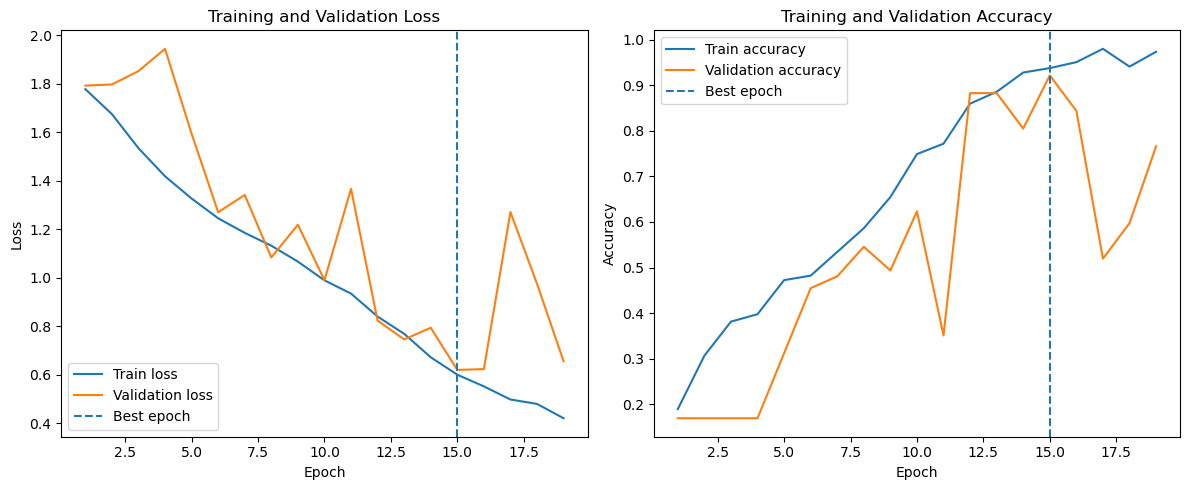

In [16]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses, label="Validation loss")
plt.axvline(best_epoch, linestyle="--", label="Best epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train accuracy")
plt.plot(epochs, val_accuracies, label="Validation accuracy")
plt.axvline(best_epoch, linestyle="--", label="Best epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
accuracy_table = pd.DataFrame([
    ["Last training accuracy", f"{train_accuracies[-1] * 100:.2f}%"],
    ["Last validation accuracy", f"{val_accuracies[-1] * 100:.2f}%"],
    ["Best validation accuracy", f"{best_val_acc * 100:.2f}%"],
    ["Best epoch", best_epoch]
], columns=["Metric", "Value"])

accuracy_table

,Metric,Value
0,Last training accuracy,97.39%
1,Last validation accuracy,76.62%
2,Best validation accuracy,92.21%
3,Best epoch,15


        I trained the model for a number of epochs and kept an eye on how well it did on both the training and validation sets. The results show that the model learned the training data very well, and the validation accuracy also went up quickly and stayed high. This means that the model was able to generalize well to the validation data.

        Compared with the earlier runs, this version was much more stable. The validation curves showed smaller fluctuations, and the best validation accuracy reached a very high value. I used early stopping and kept the best validation epoch instead of just the last one. This helped me avoid keeping a worse model from a later stage of training. Overall, the training performance was strong. The last model had a very high validation accuracy, and the training and validation curves show that it works well for this task.

### 3.5. Comments on the training performance of the model

        I trained the model for a few epochs and watched the training and validation loss and accuracy. The results show that the model learned the training data very well because the training loss got very low and the training accuracy got very high. I also checked how well the model did on the validation set after each epoch. The validation accuracy went up quickly and stayed high, which means that the model was able to generalize well to new validation data. This version of the model was more stable than the ones I ran before and gave much better validation results.

        To improve performance, I reduced the learning rate to "0.0005" and used early stopping. I saved the best validation epoch instead of just the last one. This was important because the last epoch isn't always the best one. By saving the best validation model, I was able to keep the network's strongest version. Overall, the training performance was strong. The final model reached a very high validation accuracy, and the loss curves suggest that the model is suitable for this dice classification task.

In [18]:
training_summary_table = pd.DataFrame([
    ["Last training accuracy", f"{train_accuracies[-1] * 100:.2f}%"],
    ["Last validation accuracy", f"{val_accuracies[-1] * 100:.2f}%"],
    ["Best validation accuracy", f"{best_val_acc * 100:.2f}%"],
    ["Best epoch", best_epoch],
    ["Learning rate", "0.0005"],
    ["Early stopping", "Used"]
], columns=["Metric", "Value"])

training_summary_table

,Metric,Value
0,Last training accuracy,97.39%
1,Last validation accuracy,76.62%
2,Best validation accuracy,92.21%
3,Best epoch,15
4,Learning rate,0.0005
5,Early stopping,Used


# 4. Model deployment, testing and performance evaluation

In [19]:
test_df = pd.read_csv('test.csv')
test_df.head()

,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,4,0,1,2,3,4,5,6,7,8,...,87,88,89,90,91,92,93,94,96,97
1,3,255,255,254,254,253,252,252,251,251,...,225,225,224,223,223,222,222,221,220,220
2,3,3,5,6,8,9,11,12,14,15,...,26,28,29,31,32,34,35,37,38,40
3,3,0,0,1,1,2,2,3,3,4,...,73,73,74,74,75,75,76,76,77,77
4,5,22,22,22,21,21,21,20,20,19,...,3,3,2,2,1,1,1,0,0,0


In [20]:
test_n_samples = test_df.shape[0]
test_n_columns = test_df.shape[1]
test_n_pixel_features = test_n_columns - 1
test_image_size = int(np.sqrt(test_n_pixel_features))

test_summary_table = pd.DataFrame([
    ["Image size", f"{test_image_size} x {test_image_size}"],
    ["Pixel features", test_n_pixel_features],
    ["Number of samples", test_n_samples],
    ["Number of columns", test_n_columns],
    ["Number of classes", test_df["label"].nunique()],
    ["Task type", "Multi-class classification"]
], columns=["Item", "Value"])

test_summary_table

,Item,Value
0,Image size,28 x 28
1,Pixel features,784
2,Number of samples,96
3,Number of columns,785
4,Number of classes,6
5,Task type,Multi-class classification


### 4.1. Obtaining the predicted labels from the model

In [21]:
test_df = pd.read_csv("test.csv")

test_df["class_idx"] = test_df["label"] - 1

X_test = torch.tensor(
    test_df.iloc[:, 1:785].to_numpy(dtype="float32") / 255.0
).reshape(-1, 1, 28, 28)

y_test = torch.tensor(test_df["class_idx"].to_numpy(), dtype=torch.long)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Test set size:", len(test_dataset))
print("Test image shape:", X_test.shape)
print("Test label shape:", y_test.shape)

Test set size: 96
Test image shape: torch.Size([96, 1, 28, 28])
Test label shape: torch.Size([96])


In [22]:
model.eval()

all_preds = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)

        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

        correct += (preds == y).sum().item()
        total += y.size(0)

test_acc = correct / total

print("Test accuracy:", test_acc)
print("Test accuracy (%):", test_acc * 100)

Test accuracy: 0.8645833333333334
Test accuracy (%): 86.45833333333334


        I loaded the test data from "test.csv" and changed the original labels from 1–6 to class indexes from 0–5. I then changed the pixel values to the range 0–1 and reshaped each sample into a 1 × 28 × 28 image to match the input format for the CNN. After that, I passed the test images through the trained model in evaluation mode and got the predicted labels by taking the class with the highest output score. Finally, I compared the predicted labels to the true test labels and found the final test accuracy.

### 4.2. Comparing both to the training and validation data

In [23]:
comparison_table = pd.DataFrame([
    ["Last training accuracy", f"{train_accuracies[-1] * 100:.2f}%"],
    ["Last validation accuracy", f"{val_accuracies[-1] * 100:.2f}%"],
    ["Best validation accuracy", f"{best_val_acc * 100:.2f}%"],
    ["Test accuracy", f"{test_acc * 100:.2f}%"]
], columns=["Metric", "Value"])

comparison_table

,Metric,Value
0,Last training accuracy,97.39%
1,Last validation accuracy,76.62%
2,Best validation accuracy,92.21%
3,Test accuracy,86.46%


        I checked the test accuracy and the training and validation accuracies to see how well the model worked with new data. The last training accuracy was 97.39%, the last validation accuracy was 76.62%, the best validation accuracy was 92.21%, and the final test accuracy was 86.46%.

        The test accuracy should be compared mainly with the "best validation accuracy", not only with the last validation accuracy, because I used early stopping and kept the best model during training. Based on this, the test accuracy is lower than the best validation accuracy, but it is still reasonably high. This indicates that the model exhibited commendable performance on unseen data, despite the test set being marginally more challenging than the validation set.

        The considerable difference between the final validation accuracy and the test accuracy underscores the importance of preserving the optimal validation model rather than relying solely on the last epoch. In summary, the model generalized reasonably well, yet the findings indicate a persistent gap between validation performance and final test performance.

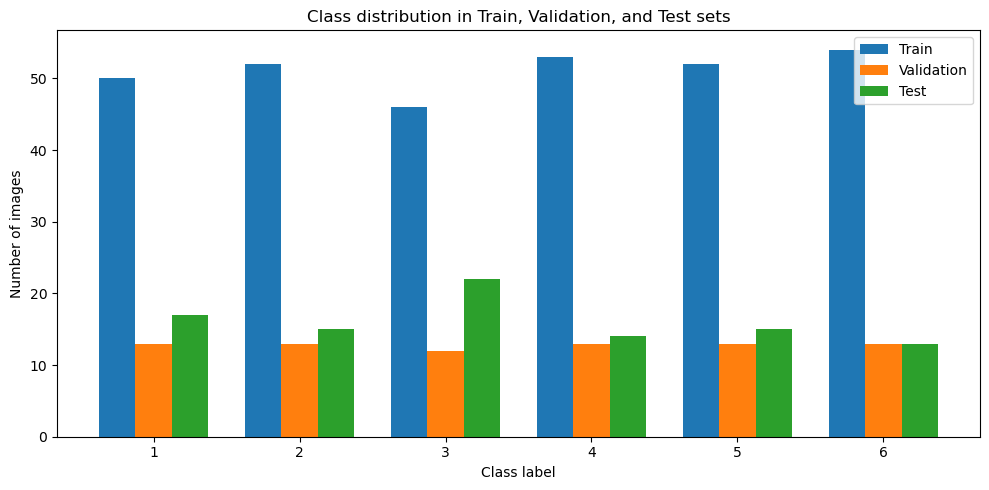

In [25]:
train_counts = train_df["label"].value_counts().sort_index()
val_counts = val_df["label"].value_counts().sort_index()
test_counts = test_df["label"].value_counts().sort_index()

classes = train_counts.index.astype(str)
x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, train_counts.values, width=width, label="Train")
plt.bar(x, val_counts.values, width=width, label="Validation")
plt.bar(x + width, test_counts.values, width=width, label="Test")

plt.xlabel("Class label")
plt.ylabel("Number of images")
plt.title("Class distribution in Train, Validation, and Test sets")
plt.xticks(x, classes)
plt.legend()
plt.tight_layout()
plt.show()

### 4.3. The factors limiting model performance

        The model doesn't see a very large number of training images, so it may not learn all the different ways the dice can be. The fact that the images are in different positions, rotations, sizes, and brightness levels also makes the classification task harder.

        The results also show that the test data might be a little harder than the validation data because the test accuracy was lower than the best validation accuracy. This means that the validation set may not fully represent the final test set. I could make the model better by giving it more training data or by using data augmentation techniques like small rotations and shifts. I could also fine-tune the model by changing the learning rate, dropout, batch size, or CNN architecture. Another way to make it better would be to use a bigger validation set or cross-validation to get a more accurate performance estimate.

### 4.4. The complexity of the model

In [26]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 148134
Trainable parameters: 148134


In [27]:
model.eval()

start_time = time.time()

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

end_time = time.time()

total_test_time = end_time - start_time
time_per_image = total_test_time / len(test_dataset)

print(f"Total prediction time on test set: {total_test_time:.4f} seconds")
print(f"Average time per image: {time_per_image:.6f} seconds")

Total prediction time on test set: 0.0351 seconds
Average time per image: 0.000366 seconds


In [28]:
complexity_table = pd.DataFrame([
    ["Total parameters", total_params],
    ["Trainable parameters", trainable_params],
    ["Test set size", len(test_dataset)],
    ["Total prediction time (s)", f"{total_test_time:.4f}"],
    ["Average time per image (s)", f"{time_per_image:.6f}"]
], columns=["Metric", "Value"])

complexity_table

,Metric,Value
0,Total parameters,148134
1,Trainable parameters,148134
2,Test set size,96
3,Total prediction time (s),0.0351
4,Average time per image (s),0.000366


        I counted the number of parameters in the model to see how complex it was. The model has 148134 parameters, and all of them can be trained. This means that the model is a medium size: it is big enough to learn useful image features, but not too big to be useful for this task. I also timed how long it took the model to make predictions on the test set. It took 0.0351 seconds to make predictions on the full test set, which had 96 images. This means that it takes an average of 0.000366 seconds to predict each image. These results show that the model is not only accurate, but also efficient. It is complicated enough to do well on the dice classification task, but still fast enough to be useful for classifying new images.

In [29]:
torch.save(model.state_dict(), "cnn_dice_model.pth")
print("Model weights saved as cnn_dice_model.pth")

Model weights saved as cnn_dice_model.pth


        I saved the fully trained model weights to a file called "cnn_dice_model.pth" using "torch.save()".

## References

- https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks/
- https://d2l.ai/chapter_convolutional-neural-networks/
- https://www.geeksforgeeks.org/machine-learning/regularization-by-early-stopping/
- https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html?utm_source=

## Appendix: Python environment
Standard environment:
- torch                      2.6.0
- torchvision                0.21.0
- transformers               4.52.1
- tokenizers                 0.21.1
- sentencepiece              0.2.0
- scikit-learn               1.6.1
- scipy                      1.15.2
- pandas                     2.2.3
- numpy                      2.2.6
- matplotlib                 3.10.3